In [222]:
import torch 
import pandas as pd 
import numpy as np 
import tiktoken
import random
import re

# Importing labelEncoder for encoding and decoding categorical values
from sklearn.preprocessing import LabelEncoder

import warnings 
warnings.filterwarnings("ignore")

In [223]:
# import kagglehub as kaghub
# df_path = kaghub.dataset_download("atifaliak/youtube-comments-dataset")
# print("Dataset stored at: ", df_path)

In [224]:
# Selecting device ('cpu' or 'gpu') based on availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Chosen Device : {device}")

Chosen Device : cuda


In [225]:
# Let's import our dataset 
df = pd.read_csv("C:\\Users\\harde\\.cache\\kagglehub\\datasets\\atifaliak\\youtube-comments-dataset\\versions\\1\\YoutubeCommentsDataSet.csv")
df.head(10)      

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive
5,we’ve been hounding my bank to adopt apple pay...,neutral
6,we only got apple pay in south africa in 20202...,positive
7,for now i need both apple pay and the physical...,neutral
8,in the united states we have an abundance of r...,positive
9,in cambodia we have a universal qr code system...,neutral


In [226]:
# Checking the info of the dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  object
dtypes: object(2)
memory usage: 287.8+ KB


In [227]:
# checking last entries
df.tail(10)

,Comment,Sentiment
18398,i am currently enrolled in a msc machine learn...,positive
18399,i came for a machine learning related talk but...,positive
18400,ive worked for about 2 years with mlcomputer v...,positive
18401,i come from a physics background and usually w...,positive
18402,back when i was learning to code i didn’t know...,neutral
18403,i really like the point about engineering tool...,positive
18404,i’ve just started exploring this field and thi...,positive
18405,excelente video con una pregunta filosófica pr...,neutral
18406,hey daniel just discovered your channel a coup...,positive
18407,this is great focus is key a playful approach ...,positive


In [228]:
# checking the longest entry in "comment" column 
longest_comment_length = max([len(str(x)) for x in df['Comment']])
print(f"longest_comment_length : {longest_comment_length}")

# checking the shortest entry in "comment" column
shortest_comment_length = min([len(str(x)) for x in df['Comment']])
print(f"shortest_comment_length : {shortest_comment_length}")

longest_comment_length : 7847
shortest_comment_length : 2


In [229]:
# Checking the null values
df.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

In [230]:
df['Sentiment'].value_counts()

Sentiment
positive    11432
neutral      4638
negative     2338
Name: count, dtype: int64

In [231]:
# getting sum of duplicates
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Number of duplicated rows: 531


In [232]:
#Remove Duplicates
df = df.drop_duplicates()

# Checking for any duplicate rows
df[df.duplicated()]

,Comment,Sentiment


In [233]:
# Clean Text (Remove Special Characters, Links, etc.)
def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'http\S+', '', text)  # Remove links
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#\w+', '', text)  # Remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    return text.strip()

# Apply text cleaning
df['Comment'] = df['Comment'].apply(clean_text)

In [234]:
# Let's make a balanced dataset and have equal samples of all type of "Sentiment" 
def create_balanced_dataset(df, target_col):
    # store the count of whichever sentiment is less in number
    cate_dict  = df[target_col].value_counts().to_dict()
    minimum_cate_value = cate_dict[min(cate_dict)]
   
    # Let's make a dataset with minimum count category 
    balanced_df = df[df[target_col] == min(cate_dict)]

    # randomly take sample from other categories upto "minimum_cate_value" and concatinate in our "balanced_df"
    for key,value in cate_dict.items():
        if key == min(cate_dict):
            continue
        else:
            cat_df = df[df[target_col] == key].sample(minimum_cate_value, random_state = 123)
            # Now concatinate the above dataset with "balanced_df"
            balanced_df = pd.concat([cat_df, balanced_df])

    return balanced_df        

In [235]:
# Call our defined function to get balanced dataset
bal_df = create_balanced_dataset(df,'Sentiment')
bal_df.head()

,Comment,Sentiment
6838,carefully explained,neutral
8063,soup messing with british people is top tier c...,neutral
16210,i rather him face off against mephisto then mo...,neutral
7466,allegedly founded by ryan cohen,neutral
17460,sometimes being an organized individual has it...,neutral


In [236]:
# Let's see our dataset's shape and other parameters
print("Dataset's Info:\n")
bal_df.info()

Dataset's Info:

<class 'pandas.core.frame.DataFrame'>
Index: 6954 entries, 6838 to 18365
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    6954 non-null   object
 1   Sentiment  6954 non-null   object
dtypes: object(2)
memory usage: 163.0+ KB


In [237]:
bal_df['Sentiment'].value_counts()
# So, now our dataset in balanced with equal target category values

Sentiment
neutral     2318
positive    2318
negative    2318
Name: count, dtype: int64

In [238]:
# let's make a copy of our "bal_df"
bal_df2 = bal_df.copy(deep = True)
bal_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6954 entries, 6838 to 18365
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    6954 non-null   object
 1   Sentiment  6954 non-null   object
dtypes: object(2)
memory usage: 163.0+ KB


In [239]:
# Let's now encode our categorical target column values
sentiment_encoder = LabelEncoder()    # Initialize and fit "Label_Encoder"
bal_df2['Encoded_Sentiment'] = sentiment_encoder.fit_transform(bal_df2['Sentiment'])
bal_df2['Encoded_Sentiment'].value_counts()

Encoded_Sentiment
1    2318
2    2318
0    2318
Name: count, dtype: int64

In [240]:
# Let's see how 'LabelEncoder' has encoded our target column
target_col_list = bal_df2['Sentiment'].value_counts().tolist()
for i in range(len(target_col_list)):
    val = sentiment_encoder.inverse_transform([i])[0]
    print(f"'{val}' is encoded as '{i}'")

'negative' is encoded as '0'
'neutral' is encoded as '1'
'positive' is encoded as '2'


In [241]:
# Now let's divide our dataset for training(70%), testing(20%),and for validation(10%)
def random_df_split(df,train_frac,val_frac):
    # Shuffling the entire dataset
    df = df.sample(frac = 1, random_state = 123).reset_index(drop = True)  # reset_index will reset the index to default

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    val_end = train_end + int(len(df) * val_frac)

    # Split the dataframe 
    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]

    return train_df, val_df, test_df   # returning the datasets

# Let's call our defined above function 
bal_df3 = bal_df2[['Comment','Encoded_Sentiment']]
train_df, val_df, test_df = random_df_split(bal_df3, 0.7, 0.1)

In [242]:
# let's see the length of our three dataset
print(f"Length of Training Dataset: {len(train_df)}")
print(f"Length of Validation Dataset: {len(val_df)}")
print(f"Length of Test Dataset: {len(test_df)}")

Length of Training Dataset: 4867
Length of Validation Dataset: 695
Length of Test Dataset: 1392


In [243]:
# So, here we can see we have some null values in training dataset, we need to take care of it.
print("Null Values in training Data:\n", train_df.isnull().sum())
print("\nNull Values in test Data:\n", test_df.isnull().sum())
print("\nNull Values in validation Data:\n",val_df.isnull().sum())

Null Values in training Data:
 Comment              0
Encoded_Sentiment    0
dtype: int64

Null Values in test Data:
 Comment              0
Encoded_Sentiment    0
dtype: int64

Null Values in validation Data:
 Comment              0
Encoded_Sentiment    0
dtype: int64


In [244]:
# Let's create a dictionary which will store our filling values for 
Null_Values_Replace_dict = {
    1 : "It is common nowdays.",
    2 : "It is actually good.",
    0 : "I think it is a bad move."
}

In [245]:
## let's define a function to deal with null & empty values in our datasets before loading them into DataLoader
def Handle_Null_Values(df,replacing_dict):

    # Let's try to find out the index where values are null and empty 
    null_indices = df[df["Comment"].isnull()].index.tolist()

    # Replacing null values with custom defined values in a dictionary
    if len(null_indices) > 0:
        df.loc[null_indices,"Comment"] = df.loc[null_indices].apply(lambda row: replacing_dict.get(row['Encoded_Sentiment'], row['Comment']),axis = 1)
        
    return df, null_indices 

In [246]:
# Let's apply above defined function to our datasets
train_df_no_Null, null_index_train_df = Handle_Null_Values(train_df,Null_Values_Replace_dict)
print(f"\nNumber of null values dealt in training data: {len(null_index_train_df)}")

val_df_no_Null, null_index_val_df = Handle_Null_Values(val_df,Null_Values_Replace_dict)
print(f"\nNumber of null values dealt in validation data: {len(null_index_val_df)}")

test_df_no_Null, null_index_test_df = Handle_Null_Values(test_df,Null_Values_Replace_dict)
print(f"\nNumber of null values dealt in test data: {len(null_index_test_df)}")



Number of null values dealt in training data: 0

Number of null values dealt in validation data: 0

Number of null values dealt in test data: 0


In [247]:
# Saving all three datasets into the folder
train_df_no_Null.to_csv("train.csv",index = None)
val_df_no_Null.to_csv("validation.csv",index = None)
test_df_no_Null.to_csv("test.csv",index = None)

In [248]:
train_df_no_Null

,Comment,Encoded_Sentiment
0,tenho grandes expectativas pro grounded t ansi...,1
1,i bet youre a great teacher im a nonnative spe...,2
2,this is such an emotional experience to know w...,1
3,everyone mumei do not google that mumei okay o...,0
4,timestamps main pic scenes effects assets ...,1
...,...,...
4862,i dont even feel upset anymore for having my d...,1
4863,you are awsome keep up the good work i watch y...,2
4864,todos que acompanhavam o hulk em quadrinhos vo...,1
4865,someone wanted to take him out but ended up hu...,0


In [249]:
## let's get our data in Input and Target batch pairs

import torch
from torch.utils.data import Dataset

class YoutubeComments_Dataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length = None, pad_token_id = 50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [tokenizer.encode(str(text)) for text in self.data['Comment']]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length

            # truncate token sequence of each row in 'Comment' if they are longer then max_length
            self.encoded_texts = [encoded_text[:max_length] for encoded_text in self.encoded_texts]

        # Pad the sequence to the longest sequence
        self.encoded_texts = [encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts]
            
    def __getitem__(self,index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]['Encoded_Sentiment']
        return (
            torch.tensor(encoded,dtype = torch.long),
            torch.tensor(label,dtype = torch.long)
        )
        
    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
            

In [250]:
# Define tokenizer
tokenizer = tiktoken.get_encoding("gpt2")

In [251]:
# Let's use the above defined class for making train_dataset, val_dataset and test_dataset
train_dataset = YoutubeComments_Dataset(csv_file = "train.csv", max_length = 1024, tokenizer = tokenizer)

# Now let's prepare dataset for testing and validation
val_dataset = YoutubeComments_Dataset(csv_file = "validation.csv",
                          max_length = train_dataset.max_length,
                          tokenizer = tokenizer)

test_dataset = YoutubeComments_Dataset(csv_file = "test.csv",
                           max_length = train_dataset.max_length,
                           tokenizer = tokenizer)

In [252]:
print(f"Training Dataset Length: {train_dataset.max_length}")
print(f"Validation Dataset Length: {val_dataset.max_length}")
print(f"Testing Dataset Length: {test_dataset.max_length}")

Training Dataset Length: 1024
Validation Dataset Length: 1024
Testing Dataset Length: 1024


In [253]:
# Checking the stored data in tokenized form
for i,(input_tensor,target_tensor) in enumerate(train_dataset):
    print(f"Idx : {i}, Input: {input_tensor}, Target: {target_tensor}")
    if i >= 5:
        break
        

Idx : 0, Input: tensor([ 1452,  8873,  4490,  ..., 50256, 50256, 50256]), Target: 1
Idx : 1, Input: tensor([   72,   731,   345,  ..., 50256, 50256, 50256]), Target: 2
Idx : 2, Input: tensor([ 5661,   318,   884,  ..., 50256, 50256, 50256]), Target: 1
Idx : 3, Input: tensor([47057,   285,  2454,  ..., 50256, 50256, 50256]), Target: 0
Idx : 4, Input: tensor([16514,   395,  9430,  ..., 50256, 50256, 50256]), Target: 1
Idx : 5, Input: tensor([ 1219,   616,  5770,  ..., 50256, 50256, 50256]), Target: 2


In [254]:
# Defining the new configurations based on downlaoded weights
# Changing two things: {context_length,qkv_bias}
NEW_CONFIG = {
    "vocab_size": 50257,      # Vocabulary size
    "context_length": 1024,   # Context length
    "emb_dim":768,            # Embedding dimension
    "n_heads":12,             # number of attentions heads in Multi-head Attention function
    "n_layers":12,            # number of transformer blocks
    "drop_rate":0.1,          # dropout rate of the neurons
    "qkv_bias":True          # Query-Key-Value bias
}

In [255]:
# Setting up a 'Assert Statement' which is checking the input context_length should be less then or equal to GPT2(124M) model's context_length which is 1024
assert train_dataset.max_length <= NEW_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {NEW_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={NEW_CONFIG['context_length']}`"
)

In [256]:
# Let's use created 'Dataset' and instantiate 'DataLoader'
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8 # Number of SMS in a batch with target

torch.manual_seed(123)

# Training DataLoader
train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers=num_workers,
    drop_last = True
)

# Testing DataLoader
test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers=num_workers,
    drop_last = False
)

# Validation DataLoader
val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers=num_workers,
    drop_last = False
)


In [257]:
print("Train Loader:")
for input_batch,target_batch in train_loader:
  pass

print("Input batch dimension:", input_batch.shape)
print("Label batch dimension:", target_batch.shape)

Train Loader:
Input batch dimension: torch.Size([8, 1024])
Label batch dimension: torch.Size([8])


In [258]:
# Checking the stored data in batches by DataLoader
for i,(input_tensor,target_tensor) in enumerate(train_loader):
    print(f"Idx : {i}, Input: {input_tensor}, Target: {target_tensor}")
    if i >= 2:
        break
        

Idx : 0, Input: tensor([[12543,  1109,   262,  ..., 50256, 50256, 50256],
        [ 1169,   269, 17896,  ..., 50256, 50256, 50256],
        [  258,  2626,   502,  ..., 50256, 50256, 50256],
        ...,
        [ 1169,  7799,   389,  ..., 50256, 50256, 50256],
        [ 1169,   652,   262,  ..., 50256, 50256, 50256],
        [ 5171,   345,   635,  ..., 50256, 50256, 50256]]), Target: tensor([0, 0, 0, 2, 2, 0, 1, 1])
Idx : 1, Input: tensor([[ 1169,  1110, 19997,  ..., 50256, 50256, 50256],
        [ 5661, 10969,   257,  ..., 50256, 50256, 50256],
        [12518,   334,   389,  ..., 50256, 50256, 50256],
        ...,
        [ 1326,   281, 46932,  ..., 50256, 50256, 50256],
        [ 8499,   477,   262,  ..., 50256, 50256, 50256],
        [17914, 18784,   349,  ..., 50256, 50256, 50256]]), Target: tensor([0, 0, 0, 1, 1, 1, 1, 1])
Idx : 2, Input: tensor([[16706,   644,   345,  ..., 50256, 50256, 50256],
        [  292,   257,   872,  ..., 50256, 50256, 50256],
        [24643,   428,  8737

In [259]:
print(f"{len(train_loader)} training batches")    # 70% data
print(f"{len(val_loader)} validation batches")    # 10% data
print(f"{len(test_loader)} test batches")         # 20% data

608 training batches
87 validation batches
174 test batches


#### Step 01: Loading Pretrained LLM Model with GPT2 weights

In [260]:
# Device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Chosen Processing Unit : {device}")

Chosen Processing Unit : cuda


In [261]:
import torch.nn as nn
import torch

# # Why we do Layer Normalization? , Ans: We need to take care of vanishing or exploding gradient problem and also reduces problem of "internal covariate shift" in the input inbetween the layers, this helps in accelerate convergence & we get to result faster.
# # Main Idea: Adjust outputs of neural network to have mean zero and variance of one (helps in speeding up the convergence)
# Now let's define the normalization class
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self,input):
    mean = input.mean(dim = -1,keepdim = True)
    variance = input.var(dim = -1, keepdim = True, unbiased = False)
    normalized_output = (input - mean) / torch.sqrt(variance + self.eps)
    return self.scale * normalized_output + self.shift

class GELU(nn.Module):
  def __init___(self):
    super().__init__()

  def forward(self,input):
    return 0.5 * input * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (input + 0.044715 * torch.pow(input,3))))


# let's now create a FeedForward neural network class
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),      # Expansion
        GELU(),   # GELU Activation
        nn.Linear(4 * cfg['emb_dim'],cfg['emb_dim'])    # Contraction
        )
      
  def forward(self,input):
    return self.layers(input)

# Let's make a "Multi-head Attention Class"
import torch.nn as nn
class MultiHeadAttention(nn.Module):

  def __init__(self,d_in,d_out,context_length,dropout, num_heads, qkv_bias = False):
    super().__init__()
    assert(d_out % num_heads == 0), "d_out must be divisible by num_heads"

    self.d_in = d_in
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim
    self.W_query = nn.Linear(d_in,d_out,bias = qkv_bias)    # Wq
    self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)    #Wk
    self.W_value = nn.Linear(d_in,d_out,bias = qkv_bias)  #W
    self.out_proj = nn.Linear(d_out,d_out)  # Linear layer to combine heads outputs
    self.dropout = nn.Dropout(dropout)    # dropout gives us the percentage of dropout to be applied on matrix
    self.register_buffer(
        "mask",torch.triu(torch.ones(context_length,context_length), diagonal = 1)
    )

  def forward(self,input):
    b,num_tokens,d_in = input.shape

    keys = self.W_key(input)
    queries = self.W_query(input)
    values = self.W_value(input)

    # We implicitly split the matrix by adding a 'num-heads' dimension
    # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
    keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
    values = values.view(b,num_tokens,self.num_heads,self.head_dim)
    queries = queries.view(b,num_tokens, self.num_heads, self.head_dim)

    # Transpose : (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
    keys = keys.transpose(1,2)    # transposing only num_tokens & num_heads
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    # Compute sclaed dot-product attention (aka self-attention) with a causal mask
    atten_score = queries @ keys.transpose(2,3)

    # Original mask truncated to the number of tokens and converted to boolean
    mask_bool = self.mask.bool()[:num_tokens,:num_tokens]

    # Use the mask to fill attention score
    atten_score.masked_fill_(mask_bool, -torch.inf)

    atten_weights = torch.softmax(atten_score / keys.shape[-1] ** 0.5, dim = -1)  # dim = -1, as we have to make sure that sum of all the rows should sum upto 1
    atten_weights = self.dropout(atten_weights)

    # context_embedding_vector Shape: (b,num_tokens,num_heads, num_dim)
    context_embedding_vector = (atten_weights @ values).transpose(1,2)

    # Combine heads, where self.d_out = self.num_heads * self.head_dim
    context_embedding_vector = context_embedding_vector.contiguous().view(b,num_tokens, self.d_out)
    context_embedding_vector = self.out_proj(context_embedding_vector)  # Optional Projection

    return context_embedding_vector

class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.multihead_attention = MultiHeadAttention(
        d_in = cfg['emb_dim'],
        d_out = cfg['emb_dim'],
        context_length = cfg['context_length'],
        dropout = cfg['drop_rate'],
        num_heads = cfg['n_heads'],
        qkv_bias = cfg['qkv_bias']
    )
    self.feedforward = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg['emb_dim'])
    self.norm2 = LayerNorm(cfg['emb_dim'])
    self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

  def forward(self,input):
    # Shortcut connection for attention block
    original_input = input
    input = self.norm1(input)
    input = self.multihead_attention(input)    # Shape[batch_size,num_tokens, emb_size]
    input = self.drop_shortcut(input) # Avoid gradient diminshing problem
    input = input + original_input   # Add the original input back

    # ShortCut connection for Feed Forward block
    original_input = input
    input = self.norm2(input)
    input = self.feedforward(input)
    input = self.drop_shortcut(input)
    input = input + original_input    # Add the original input back
    output = input
    return output

# Let's us a make a GPT Model Class

class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
    self.pos_emb = nn.Embedding(cfg['context_length'],cfg['emb_dim'])
    self.dropout = nn.Dropout(cfg['drop_rate'])

    self.Transformer_Blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg['n_layers'])])

    self.final_norm = LayerNorm(cfg['emb_dim'])
    self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'],bias = False)

  # Input passsed: "Every effort moves you"
  def forward(self,input_token_ids):
    batch_size, seq_len = input_token_ids.shape
    token_embeddings = self.tok_emb(input_token_ids)
    position_embeddings = self.pos_emb(torch.arange(seq_len,device = input_token_ids.device))
    embedding_vector = token_embeddings + position_embeddings
    embedding_vector = self.dropout(embedding_vector)    # Helps for avoiding overfitting
    embedding_vector = self.Transformer_Blocks(embedding_vector)
    embedding_vector = self.final_norm(embedding_vector)
    logits = self.out_head(embedding_vector)
    return logits


# Let's define a function based on our steps till now to predict new words/tokens
# eos_id = End of Sample Id
def generate_new_tokens(model, idx, max_new_tokens, context_size, temp = 0.0, top_k = None, eos_id = None):
  # For_loop is same as before : Get_Logits, and only focus on last time step
  for _ in range(max_new_tokens):
    idx_cond = idx[:,-context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:,-1,:]

    # New: Filter logits with top_k sampling
    if top_k is not None:
      # Keep only top_k values
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:,-1]
      logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), other = logits)

    # New: Apply temperature scaling
    if temp > 0.0:
      logits = logits / temp
      probs = torch.softmax(logits, dim = -1) # Applying Softmax to get logits into probabilities
      idx_next = torch.multinomial(probs, num_samples = 1) # Sample from the distribution

    # Otherwise don't change anything in logits, just apply Softmax
    else:
      probs = torch.softmax(logits,dim = -1)
      idx_next = torch.argmax(probs, dim = -1, keepdim = True)

    if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered
      break

    # Same as before: append predicted index to the running sequence
    idx = torch.cat((idx, idx_next), dim =1)  # Shape : {Batch_size, num_tokens + 1}

  return idx

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)   # added batch dimension
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # remove batch dimension
  return tokenizer.decode(flat.tolist())


In [262]:
import requests
import os
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm

def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M","355M","774M","1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    filenames = [
        "checkpoint", "encoder.json","hparams.json","model.ckpt.data-00000-of-00001","model.ckpt.index","model.ckpt.meta","vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir,exist_ok = True)
    for filename in filenames:
        file_url = os.path.join(base_url,model_size, filename)
        file_path = os.path.join(model_dir,filename)
        download_file(file_url,file_path)


    ## We have reached here until now ---> we have downloaded the files on our local machine.

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json")))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params

def download_file(url, destination):
    try:
        # Send a GET request to download the file, disabling SSL verification
        response = requests.get(url, stream=True, verify=False)

        # Get the total file size from headers, defaulting to 0 if not present
        file_size = int(response.headers.get("content-length", 0))

        # Check if file exists and has the same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return

        # Define the block size for reading the file
        block_size = 1024  # 1 Kilobyte

        # Initialize the progress bar with total file size
        progress_bar_description = url.split("/")[-1]  # Extract filename from URL
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
            # Open the destination file in binary write mode
            with open(destination, "wb") as file:
                # Iterate over the file data in chunks
                for chunk in response.iter_content(block_size):
                    progress_bar.update(len(chunk))  # Update progress bar
                    file.write(chunk)  # Write the chunk to the file

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        print(f"Please check the URL: {url}")

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [263]:
# We are running and storing the params of gpt-2 "124M para" in two variables
settings, params = download_and_load_gpt2(model_size = "124M" , models_dir = "C:\\Users\\harde\\Documents\\LLMs (GEN AI)\\gpt2")

File already exists and is up-to-date: C:\Users\harde\Documents\LLMs (GEN AI)\gpt2\124M\checkpoint
File already exists and is up-to-date: C:\Users\harde\Documents\LLMs (GEN AI)\gpt2\124M\encoder.json
File already exists and is up-to-date: C:\Users\harde\Documents\LLMs (GEN AI)\gpt2\124M\hparams.json
File already exists and is up-to-date: C:\Users\harde\Documents\LLMs (GEN AI)\gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: C:\Users\harde\Documents\LLMs (GEN AI)\gpt2\124M\model.ckpt.index
File already exists and is up-to-date: C:\Users\harde\Documents\LLMs (GEN AI)\gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: C:\Users\harde\Documents\LLMs (GEN AI)\gpt2\124M\vocab.bpe


In [264]:
print("Settings: ", settings)
print("Parameters dictionary keys: ", params.keys())

Settings:  {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameters dictionary keys:  dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [265]:
# Define a function for assigning the weights/parameter values after comparing the requirements
def assign(left, right):
  if left.shape != right.shape:   # Checking the shape and size of weights to be replaced
    raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))

In [266]:
# Define a function for loading the pre-trained weights from gpt2 into our own created model
import numpy as np

def load_weights_into_gpt(gpt,params):
  gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
  gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

  for b in range(len(params['blocks'])):
    # Separating query,key, value weights matrices of gpt-2(124M)
    q_w,k_w, v_w = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis = -1)

    # Updating the transformer blocks query,key,value weights matrices with gpt-2 downloaded ones which are getting separated above
    gpt.Transformer_Blocks[b].multihead_attention.W_query.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_query.weight, q_w.T)
    gpt.Transformer_Blocks[b].multihead_attention.W_key.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_key.weight, k_w.T)
    gpt.Transformer_Blocks[b].multihead_attention.W_value.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_value.weight, v_w.T)

    # Separating query,key,value bias matrices of gpt-2(124M)
    q_b, k_b, v_b = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis = -1)

    # Updating the transformer blocks query,key,value bias matrices with gpt-2 downloaded ones which are getting separated above
    gpt.Transformer_Blocks[b].multihead_attention.W_query.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_query.bias, q_b)
    gpt.Transformer_Blocks[b].multihead_attention.W_key.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_key.bias, k_b)
    gpt.Transformer_Blocks[b].multihead_attention.W_value.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_value.bias, v_b)

    # Updating the "out_proj" matrix weights with gpt-2 ones
    gpt.Transformer_Blocks[b].multihead_attention.out_proj.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.Transformer_Blocks[b].multihead_attention.out_proj.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])

    # Updating the "FeedForward" matrices of layer0, layer2 with gpt-2 ones
    gpt.Transformer_Blocks[b].feedforward.layers[0].weight = assign(gpt.Transformer_Blocks[b].feedforward.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.Transformer_Blocks[b].feedforward.layers[0].bias = assign(gpt.Transformer_Blocks[b].feedforward.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])

    gpt.Transformer_Blocks[b].feedforward.layers[2].weight = assign(gpt.Transformer_Blocks[b].feedforward.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.Transformer_Blocks[b].feedforward.layers[2].bias = assign(gpt.Transformer_Blocks[b].feedforward.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])

    # Updating the "LayerNorm" matrices of norm1, norm2 with gpt-2 ones
    gpt.Transformer_Blocks[b].norm1.scale = assign(gpt.Transformer_Blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
    gpt.Transformer_Blocks[b].norm1.shift = assign(gpt.Transformer_Blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])

    gpt.Transformer_Blocks[b].norm2.scale = assign(gpt.Transformer_Blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
    gpt.Transformer_Blocks[b].norm2.shift = assign(gpt.Transformer_Blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])

  gpt.final_norm.scale = assign(gpt.final_norm.scale,params["g"])
  gpt.final_norm.shift = assign(gpt.final_norm.shift,params["b"])
  gpt.out_head.weight = assign(gpt.out_head.weight,params["wte"])  # Same token embedding weights have been used for replacing weight for this layer


In [267]:
# Checking the configuration for the model
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': True}

In [268]:
# Updating the defined class of GPT model architecture with GPT-2 Pre-trained weights
model = GPTModel(NEW_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

In [269]:
# Now let's see the output of our pre_trained model
output_token_ids = generate_new_tokens(model = model,
    idx = text_to_token_ids("Hardeep is a genius why?", tokenizer),
    max_new_tokens = 20,
    context_size = NEW_CONFIG['context_length'],
    top_k = 50,
    temp = 1.5
)

print("\n Output After Scaling: \n", token_ids_to_text(output_token_ids,tokenizer))


 Output After Scaling: 
 Hardeep is a genius why? How often do companies run these competitions for free when no sponsor has money to support them to maintain a


In [270]:
# let's check how our pretrained model will behave now for a Sentiment classification
model.to(device)    # Setting model to 'cuda' gpu device
text_2 = train_df['Comment'][1]     # taking a sample value from training data

output_token_ids = generate_new_tokens(
    model = model,
    idx = text_to_token_ids(text_2,tokenizer).to(device),
    max_new_tokens=23,
    context_size=NEW_CONFIG['context_length']
)

print(token_ids_to_text(output_token_ids,tokenizer))

i bet youre a great teacher im a nonnative speaker of english though i can understand you  your way of teaching is admirable but i cant understand your way of teaching im a native speaker of english though i can understand you

Anonymous 05


In [271]:
# Our pre-trained LLM model is giving output but in form of next word prediction, we need to change it based on our classification needs

In [272]:
# Checking the Model layers status 
for name,param in model.named_parameters():
    print(f"Layer: {name} || Trainable: {param.requires_grad}")

Layer: tok_emb.weight || Trainable: True
Layer: pos_emb.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_query.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_query.bias || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_key.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_key.bias || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_value.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_value.bias || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.out_proj.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.out_proj.bias || Trainable: True
Layer: Transformer_Blocks.0.feedforward.layers.0.weight || Trainable: True
Layer: Transformer_Blocks.0.feedforward.layers.0.bias || Trainable: True
Layer: Transformer_Blocks.0.feedforward.layers.2.weight || Trainable: True
Layer: Transformer_Blocks.0.feedforward.layers.2.

In [273]:
# We Need to freeze all the layers of the imported model and later we can unfreeze whichever is required
for param in model.parameters():
    param.requires_grad = False

#### Step 02: Modifying the architecture by adding a classification head

In [274]:
# Let's see our LLM Model structure
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (Transformer_Blocks): Sequential(
    (0): TransformerBlock(
      (multihead_attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feedforward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (multihead_attention): MultiHeadAt

In [275]:
# We will be changing the "out_head" out_features from 50257 to 3 ("0","1","2") as we have only three classification to be predicted

torch.manual_seed(123)

num_target_classes = 3  # {"Positive", "Negative", "Neutral"}
model.out_head = torch.nn.Linear(in_features= NEW_CONFIG['emb_dim'], out_features=num_target_classes).to(device)

#### Step 03: Select which layers to be fine-tuned?
We will fine-tune:
1.   Final output head
2.   Final transformer block
3.   Final LayerNorm module

In [276]:
# Now let's make the parameters of the last transformer and LayerNorm to be trainable

# Last transformer block
for param in model.Transformer_Blocks[-1:].parameters():
  param.requires_grad = True

# LayerNorm
for param in model.final_norm.parameters():
  param.requires_grad = True

In [277]:
# Checking the Model layers status 
for name,param in model.named_parameters():
    print(f"Layer: {name} || Trainable: {param.requires_grad}")

Layer: tok_emb.weight || Trainable: False
Layer: pos_emb.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.bias || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.weight || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.bias || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.2.weight || Trainable: False
Layer: Transformer_Blocks.0.feedforw

In [278]:
input_text = "Do you have time"
inputs = text_to_token_ids(input_text,tokenizer).to(device)

with torch.no_grad():
  outputs = model(inputs)

print("Outputs: ", outputs, "\nShape: ",outputs.shape)
# We can see here we have only three outputs as expected

Outputs:  tensor([[[-1.6291,  1.0288,  0.0506],
         [-3.7672,  7.4932,  2.2589],
         [-2.3098,  6.6433,  2.8071],
         [-3.6420,  4.0286,  2.3041]]], device='cuda:0') 
Shape:  torch.Size([1, 4, 3])


In [279]:
# Extracting the last last token
print("Last output token: ",outputs[:,-1,:])

Last output token:  tensor([[-3.6420,  4.0286,  2.3041]], device='cuda:0')


In [280]:
# Let's convert the logits into probabilities and get the final predicted category
probas = torch.softmax(outputs[:,-1,:],dim = -1)
label = torch.argmax(probas)
print("Class Label:", label.item())

Class Label: 1


#### Step 05: Calculate the accuracy and classification loss

In [281]:
# let's define a DataLoader's batch shuffler
def get_random_batches(dataloader, num_batches = 5):
    dataloader_iter = iter(dataloader)
    return [next(dataloader_iter) for _ in range(num_batches)]  # randomly select as we iterate


In [282]:
# Let's define a "Accuracy Calculation" method
def calc_accuracy_loader(data_loader,model,device,num_batches = None):
    model.eval();
    correct_predictions, num_examples = 0,0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    random_batches = get_random_batches(data_loader, num_batches)   # Getting random batches out of whole dataloader
    
    for input_batch, target_batch in random_batches:
        input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    
        with torch.no_grad():
            logits = model(input_batch)[:,-1,:]   # Logits of the last output token
        predicted_labels = torch.argmax(torch.softmax(logits,dim = -1), dim = -1)
        
        num_examples += predicted_labels.shape[0]
        correct_predictions += (predicted_labels == target_batch).sum().item()
        
    return correct_predictions / num_examples

In [283]:
# Now let's call this "calc_accuracy_loader" method for all three datasets
torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches = 5)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches = 5)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches = 5)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 32.50%
Validation Accuracy: 30.00%
Test Accuracy: 37.50%


In [284]:
# Let's defined Loss Function for this ML Model which would be "Categorical Cross Entropy", formula : -Sum(Yi * log(Pi)), here i is the number of samples
def  calc_loss_batch(input_batch, target_batch, model, device):
  # Setting the device to deal with input,output data processing
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)

  logits = model(input_batch)[:,-1,:]   # Taking output logit of last token
  loss = torch.nn.functional.cross_entropy(logits,target_batch)
  return loss


# Defining "LOSS" function calculation method for multiple batches
def calc_loss_loader(data_loader,model,device,num_batches = None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    random_batches = get_random_batches(data_loader, num_batches)   # Getting random batches out of whole dataloader
    
    for input_batch, target_batch in random_batches:
        loss = calc_loss_batch(input_batch, target_batch,model,device)
        total_loss += loss.item()
    
    return total_loss/num_batches

# Now let's call this "calc_loss_loader" method for all three datasets to check defined function
torch.manual_seed(123)

with torch.no_grad():
  train_loss = calc_loss_loader(train_loader, model, device, num_batches = 5)
  val_loss = calc_loss_loader(val_loader, model, device, num_batches = 5)
  test_loss = calc_loss_loader(test_loader, model, device, num_batches = 5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 4.488
Validation loss: 4.881
Test loss: 3.526


#### Step 06: Finetune Model on Supervised Data
Define Training Loop

      Steps to be followed for training LLM model for a specific task:
      - For each training epoch
          - For each batch in training dataset
              - Reset the loss gradients from previous batch
              - Calculate the loss on current batch
              - Backward pass to calculate the loss gradients  (finding partial differentiation of Loss function wrt weights)
              - Update model weights using loss gradients (finding & updating new weights based on formula: Weight_new = Weight_old - (Learning_rate * partial differentiation of Loss function wrt weights))
              - Print training and validation set losses
          - New: Calculate classification accuracy after current epoch


In [285]:
# Defining the 'Evaluate Model' functions
def evaluate_model(model,train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches = eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches = eval_iter)
  model.train()
  return train_loss, val_loss

In [289]:
# Define LLM Model training function
def Classifier_Model_Training(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter,patience = None):
    
    # Initialize lists to track losses and exampls seen
    train_losses,val_losses,train_accs, val_accs = [],[],[],[]
    examples_seen, global_step = 0,-1
    best_val_loss = float("inf")
    best_val_acc = 0.0
    patience_counter = 0
    
    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch,target_batch in train_loader:
          optimizer.zero_grad()  # Reseting loss gradients from previous batch iteration
          loss = calc_loss_batch(input_batch, target_batch, model, device)    # Calculating loss
          loss.backward()  # Calculate the loss gradients
          optimizer.step()  # Updating model weights using loss gradients(found in above step)
          examples_seen += input_batch.shape[0]  # tracking examples instead of tokens
          global_step += 1    # Tracking number of batches
        
          # Optional evaluation step
          if global_step % eval_freq == 0:
            train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Ep {epoch+1} (Step {global_step:03d}):"
                  f"Train Loss {train_loss:.3f}, Val loss {val_loss:.3f}")
              
        # Calculating accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches = eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches = eval_iter)
        print(f"Training Accuracy: {train_accuracy * 100:.2f}% | ", end  = "")
        print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        # Storing lowest loss recorded
        if val_loss < best_val_loss:
            best_val_loss = val_loss

        # **training stopping part based on validation data accuracy**
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"\nNo improvement for {patience_counter} epoch(s).\n")
        
        # Stop training if no improvement in `patience` epochs or accuracy
        if patience is not None:
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered based on 'patience_counter'.")
                print(f"\nBest Val_loss: {best_val_loss:.3f}, Best Val_Accuracy: {best_val_acc * 100:.2f}%, At patience counter: {patience_counter}")
                break
        # else:
        #     if best_val_acc > val_accuracy:
        #         print(f"\nEarly stopping triggered based on decrease in 'Accuracy'.")
        #         print(f"\nBest Val_loss: {best_val_loss:.3f}, Best Val_Accuracy: {best_val_acc * 100:.2f}%, At patience counter: {patience_counter}")
        #         break
    
    return train_losses, val_losses, train_accs,val_accs,examples_seen, best_val_loss, best_val_acc
    


In [287]:
for name, param in model.named_parameters():
    print(f"Layer: {name}, || Trainable: {param.requires_grad}")

Layer: tok_emb.weight, || Trainable: False
Layer: pos_emb.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.bias, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.bias, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.bias, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.bias, || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.weight, || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.bias, || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.2.weight, || Trainable: False
Layer: Transformer_Bloc

In [288]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (Transformer_Blocks): Sequential(
    (0): TransformerBlock(
      (multihead_attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feedforward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (multihead_attention): MultiHeadAt

##### Excessive regularization (dropout, weight decay) can prevent the model from learning during initial epochs.
##### Solution:
Reduce dropout rates (e.g., from 0.3 to 0.1).
Lower weight decay slightly in the optimizer (e.g., weight_decay=0.01 instead of 0.1).

In [290]:
# Let's do training/fine-tuning of our pre-trained GPT2(124M) LLM
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.01)

num_epochs = 10
train_losses, val_losses, train_accs, val_accs, examples_seen, best_val_loss, best_val_acc = Classifier_Model_Training(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=100, eval_iter=5
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000):Train Loss 4.960, Val loss 2.681
Ep 1 (Step 100):Train Loss 1.112, Val loss 1.089
Ep 1 (Step 200):Train Loss 1.127, Val loss 1.100
Ep 1 (Step 300):Train Loss 1.122, Val loss 1.099
Ep 1 (Step 400):Train Loss 1.095, Val loss 1.103
Ep 1 (Step 500):Train Loss 1.094, Val loss 1.082
Ep 1 (Step 600):Train Loss 1.066, Val loss 1.031
Training Accuracy: 47.50% | Validation Accuracy: 40.00%
Ep 2 (Step 700):Train Loss 1.015, Val loss 1.048
Ep 2 (Step 800):Train Loss 1.038, Val loss 1.072
Ep 2 (Step 900):Train Loss 1.066, Val loss 1.056
Ep 2 (Step 1000):Train Loss 0.926, Val loss 0.957
Ep 2 (Step 1100):Train Loss 0.919, Val loss 1.030
Ep 2 (Step 1200):Train Loss 0.974, Val loss 1.027
Training Accuracy: 50.00% | Validation Accuracy: 55.00%
Ep 3 (Step 1300):Train Loss 0.985, Val loss 0.965
Ep 3 (Step 1400):Train Loss 0.968, Val loss 0.978
Ep 3 (Step 1500):Train Loss 0.992, Val loss 0.852
Ep 3 (Step 1600):Train Loss 0.966, Val loss 0.975
Ep 3 (Step 1700):Train Loss 0.799, Val loss 0.78

In [291]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

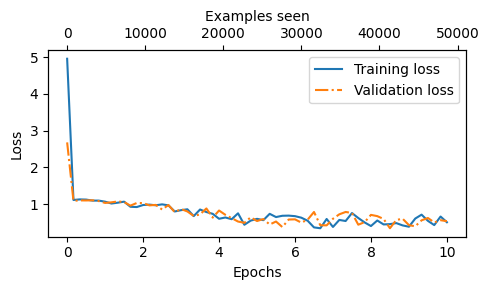

In [292]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

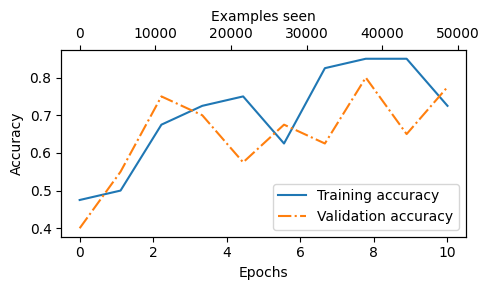

In [293]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [294]:
# Now call the trained model to get the accuracy on all three datasets
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model,device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 80.26%
Validation Accuracy: 76.98%
Test Accuracy: 75.14%


In [295]:
def Classify_Comment(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return sentiment_encoder.inverse_transform([predicted_label])[0]
    

In [296]:
# Let's test our trained model's output
torch.manual_seed(123)
model.to(device)
for idx,row in test_df.iloc[:10,:].iterrows():
    input_text = row['Comment']
    
    response = Classify_Comment(
    input_text, model, tokenizer, device, max_length=train_dataset.max_length
    )   
    # get the correct response inverse_encoded info
    corr_res = sentiment_encoder.inverse_transform([row['Encoded_Sentiment']])[0]
    
    print("Input Text: \n", input_text)
    print(f"\n Correct Response: \n >> {corr_res}")
    print(f"\n Model Response: \n >> {response}")
    print("#####################################################")

Input Text: 
 i am getting close to perfect in writing and math but i am getting like anywhere between  wrong in reading section constantly wiuthout any real pattern any tips

 Correct Response: 
 >> negative

 Model Response: 
 >> neutral
#####################################################
Input Text: 
 gems report out of order animatronics w freddy w chica t freddy t mangle t bb has been deemed unfit for interview procedures do not attempt to engage subjects may become hostile gems gems facility within the last  hours has experienced multiple breaches concerning containment list including withered plastics nightmares individual subjects include william afton springtrap marionette contained within lefty amalgamation ennard golden freddy balloon boy at approximately redacted an explosion was witnesseddetected within the gems facility currently were investigating the whereabouts of the missing subjects updates will be posted if evidence is found at redacted in a heavily wooded area le

In [298]:
# We should also store the history values of AdamW optimizer of model, so we can store both things single time
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.00005, weight_decay = 0.1)

torch.save({
    "model_state_dict":model.state_dict(),
    "optimizer_state_dict":optimizer.state_dict(),
    },"fine_tuned_GPT2(124M)_model_and_optimizer.pth")


In [ ]:
# # In this way, we can train & store parameters/optimzer of our model and can import,continue training from their after.
# import torch
# checkpoint = torch.load("/content/drive/MyDrive/GEN AI (LLMs)/Instruction-Based Fine-Tuning/trained_model_and_optimizer.pth")
# model = GPTModel(NEW_CONFIG)
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer = torch.optim.AdamW(model.parameters(), lr = 0.00005, weight_decay = 0.1)
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# model.eval();